In [1]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [2]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


In [3]:
import matplotlib.pyplot as plt
import numpy as np

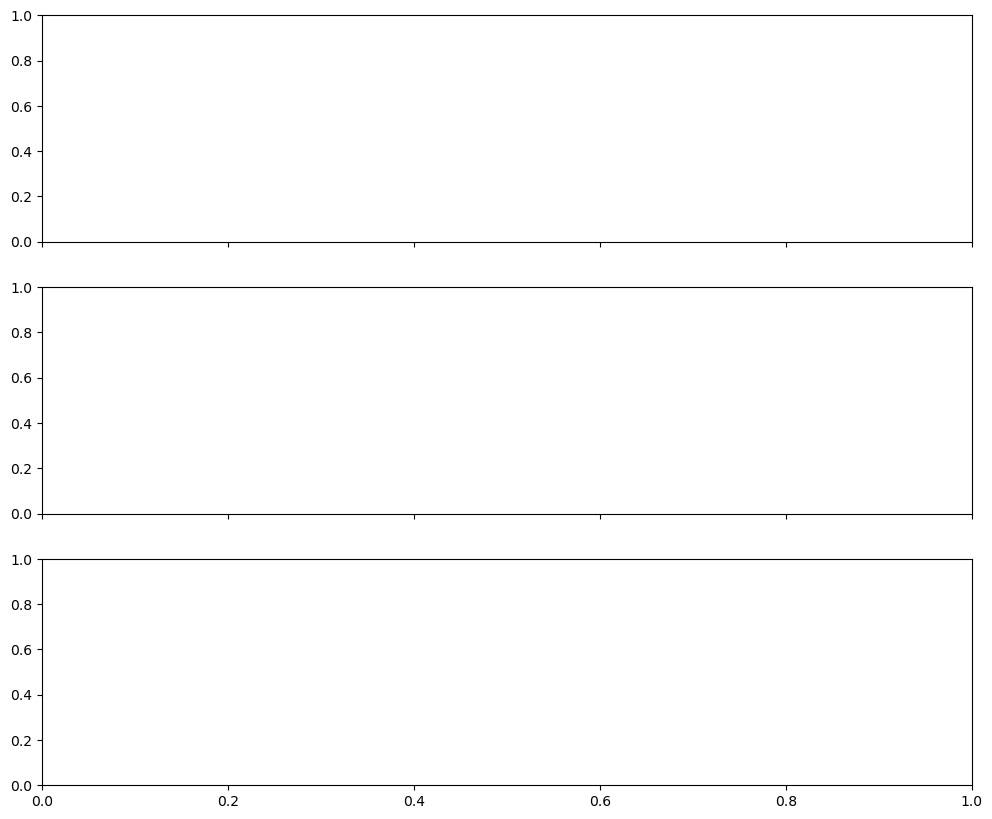

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

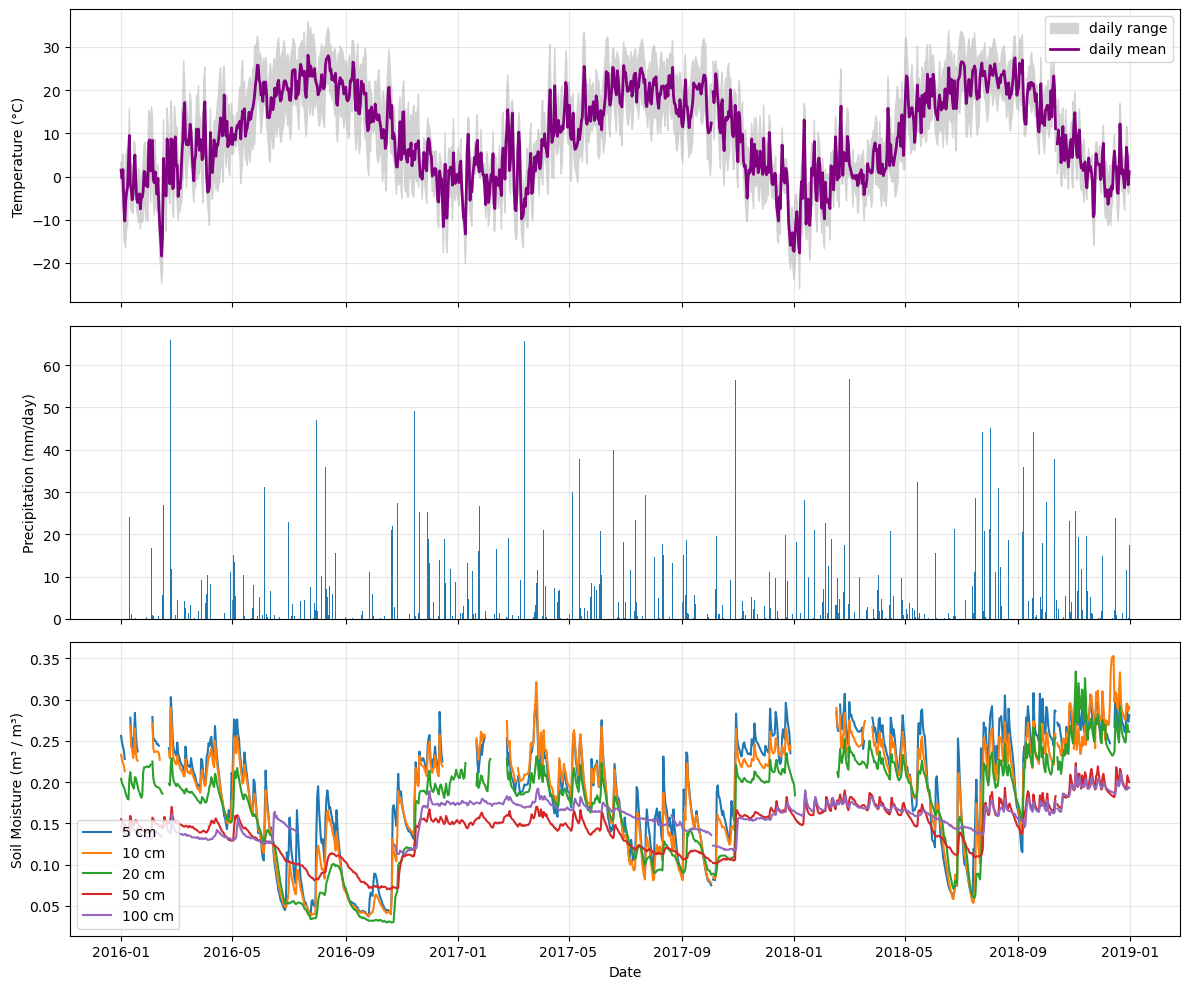

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].fill_between(date, t_daily_min, t_daily_max, color='lightgray', label='daily range')
axes[0].plot(date, t_daily_mean, color='purple', linewidth=2, label='daily mean')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(loc='upper right')

axes[1].bar(date, p_daily_calc, color='C0')
axes[1].set_ylabel('Precipitation (mm/day)')

axes[2].plot(date, soil_moisture_5, label='5 cm')
axes[2].plot(date, soil_moisture_10, label='10 cm')
axes[2].plot(date, soil_moisture_20, label='20 cm')
axes[2].plot(date, soil_moisture_50, label='50 cm')
axes[2].plot(date, soil_moisture_100, label='100 cm')
axes[2].set_ylabel('Soil Moisture (m³ / m³)')
axes[2].set_xlabel('Date')
axes[2].legend(loc='lower left')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
import xarray as xr

ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'

ds = xr.open_dataset(ds_url, decode_times=False, engine="pydap")

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

ValueError: unrecognized engine 'pydap' must be one of your download engines: ['scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

In [15]:
!pip install pydap

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.4/115.4 KB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 KB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 KB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 KB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 KB 5.2 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [21]:
temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

NameError: name 'ds' is not defined

In [1]:
import xarray as xr

ds_url = "http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods"

ds = xr.open_dataset(ds_url, decode_times=False, engine="pydap")

ValueError: unrecognized engine 'pydap' must be one of your download engines: ['scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

In [2]:
!pip install pydap

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import xarray as xr

ds_url = "http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods"
ds = xr.open_dataset(ds_url, decode_times=False, engine="pydap")

ValueError: unrecognized engine 'pydap' must be one of your download engines: ['scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

In [2]:
import sys
!{sys.executable} -m pip install pydap

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.2 MB/s  0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 3/4 [pydap]ts-cache]  WARNING: The scripts dods and pydap are installed in '/home/emf2229/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pydap]


In [3]:
import xarray as xr
print(xr.backends.list_engines())

{'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}


In [4]:
import sys
!{sys.executable} -m pip install pydap

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import xarray as xr

ds_url = "http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods"

ds = xr.open_dataset(ds_url, decode_times=False)

/home/emf2229/.local/lib/python3.11/site-packages/pydap/handlers/dap.py:143: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


In [2]:
temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

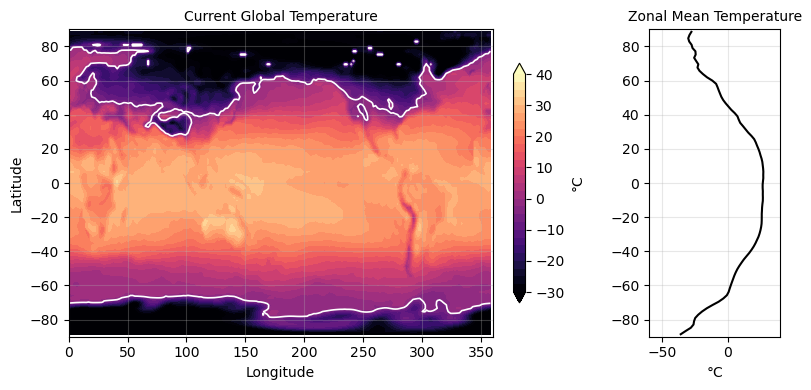

In [28]:
import matplotlib.pyplot as plt
import numpy as np

zonal_mean = np.mean(temp, axis=1)

levels = np.arange(-30, 41, 2.5)

fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 4),
    gridspec_kw={'width_ratios': [4, 1]}
)

filled = axes[0].contourf(lon, lat, temp, levels=levels, cmap='magma', extend='both')

axes[0].contour(lon, lat, temp, levels=[-5], colors='white', linewidths=1.2, linestyles='solid')

axes[0].set_title('Current Global Temperature', fontsize=10)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_xlim(0, 360)
axes[0].set_ylim(-90, 90)
axes[0].grid(True, alpha=0.3)

cbar = plt.colorbar(filled, ax=axes[0], shrink=0.78, pad=0.04)
cbar.set_label('°C')
cbar.set_ticks(np.arange(-30, 41, 10))

axes[1].plot(zonal_mean, lat, color='black', linewidth=1.5)
axes[1].set_title('Zonal Mean Temperature', fontsize=10)
axes[1].set_xlabel('°C')
axes[1].set_xlim(-60, 40)
axes[1].set_ylim(-90, 90)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
import pooch
import numpy as np

fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')

depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

Unzipping contents of '/home/emf2229/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/emf2229/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


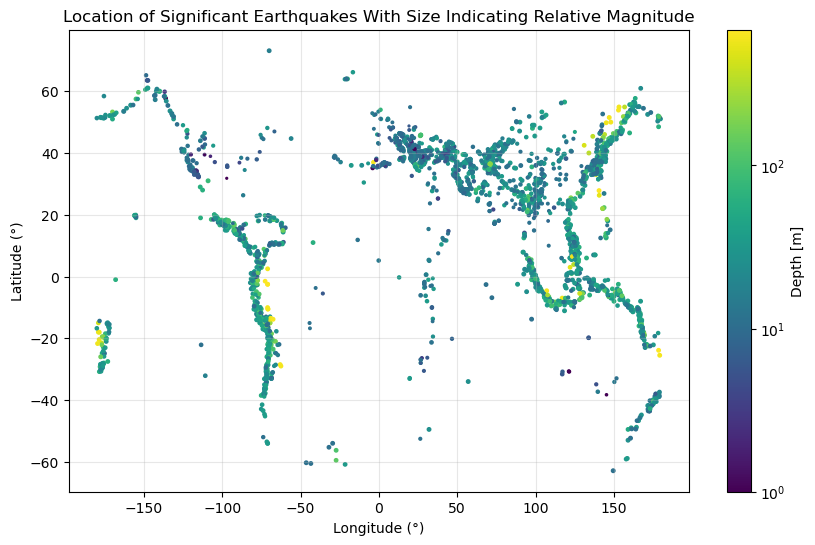

In [35]:
import matplotlib.pyplot as plt
import numpy as np

log_depth = np.log10(depth + 1)

plt.figure(figsize=(10, 6))

sc = plt.scatter(longitude, latitude, c=log_depth, s=magnitude/100 * 80)

plt.title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(sc)
cbar.set_label('Depth [m]')
cbar.set_ticks([0,1,2])
cbar.set_ticklabels([r'$10^0$', r'$10^1$', r'$10^2$'])

plt.show()